<a href="https://colab.research.google.com/github/Truptinaikwadi/Gen-Ai-task-assesment/blob/main/Task_4_Feb_Internship_NLP_Fine_Tuning_BERT_on_Kaggle_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Assignment**: **Fine-Tuning BERT on a Kaggle Dataset**

**Objective**

Learn BERT fine-tuning, use transformer pipelines, perform experiments, and evaluate model performance using multiple metrics.

**Tools and Technologies**


Python

Hugging Face Transformers

PyTorch

Colab


In [1]:
# install transformers library
!pip install transformers

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizer

# specify GPU (BERT has millions of parameters → training is very slow on CPU.
# GPU can process many operations in parallel, so training is much faster.)
device = torch.device("cuda")

Step 1: Data Preprocessing

In [3]:
# load dataset
df = pd.read_csv("/content/Twitter_Data.csv")
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
df.shape

(162980, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [6]:
df=df.rename(columns={'category': 'label','clean_text':'text'})

In [7]:
df['text'] = df['text'].fillna("").astype(str)

In [8]:
print(df['label'].isnull().sum())

7


In [9]:
print(df[df['label'].isnull()].head())

                                                     text  label
130448  the foundation stone northeast gas grid inaugu...    NaN
155642  dear terrorists you can run but you cant hide ...    NaN
155698  offense the best defence with mission shakti m...    NaN
155770  have always heard politicians backing out thei...    NaN
158693  modi government plans felicitate the faceless ...    NaN


In [10]:
df = df.dropna(subset=['label'])

In [11]:
print(df['label'].isnull().sum())

0


In [12]:
# check class distribution
df['label'].value_counts(normalize = True)

,proportion
label,
1.0,0.443325
0.0,0.338786
-1.0,0.217889


Step 2: Data Splitting

In [28]:
train_text, temp_text, train_labels, temp_labels = train_test_split(
    df['text'], df['label'],
    random_state=2018,
    test_size=0.3,
    stratify=df['label']  # 30 % train data
)

val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text, temp_labels,
    random_state=2018,
    test_size=0.5,
    stratify=temp_labels  #15 %validation data
)

In [29]:
import torch
import torch.nn as nn
from transformers import AutoModel, BertTokenizer, BertTokenizerFast

# import BERT-base pretrained model
bert = AutoModel.from_pretrained('bert-base-uncased')

# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NameError: name 'BertTokenizerFast' is not defined

In [30]:
# it for single text tokenization
text = df['text'][0]

sent_id = tokenizer(
    text,
    padding=True,
    truncation=True,
    return_tensors='pt'
)

In [31]:
#it for real padding and zero token
print(sent_id)

{'input_ids': tensor([[  101,  2043, 16913,  2072,  5763,  1523,  6263,  2231,  4555, 10615,
          1524,  3517,  2032,  4088,  1996,  3697,  3105, 29455,  1996,  2110,
          2339,  2515,  2202,  2086,  2131,  3425,  2110,  2323,  1998,  2025,
          2449,  1998,  2323,  6164,  8827,  2271,  1998,  8436,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


Step 3: Tokenization

In [32]:
train_text = train_text.fillna("").astype(str)

<Axes: >

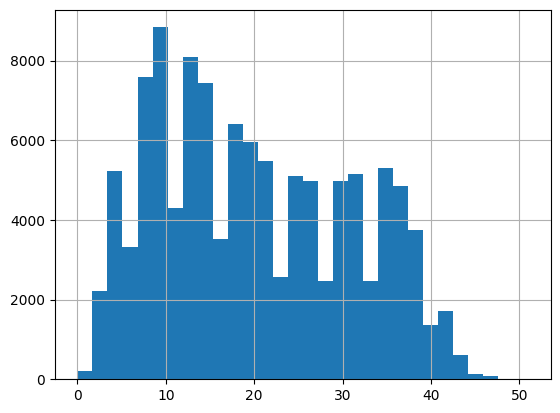

In [33]:
# get length of all the messages in the train set
seq_len = [len(i.split()) for i in train_text]

pd.Series(seq_len).hist(bins = 30)

In [34]:

train_texts = train_text.fillna("").astype(str).tolist()
val_texts = val_text.fillna("").astype(str).tolist()
test_texts = test_text.fillna("").astype(str).tolist()


max_seq_len = 64 # you can adjust based on your data


tokens_train = tokenizer(
    train_texts,
    max_length=max_seq_len,
    padding='max_length',
    truncation=True,
    return_token_type_ids=False,
    return_tensors='pt'
)

tokens_val = tokenizer(
    val_texts,
    max_length=max_seq_len,
    padding='max_length',
    truncation=True,
    return_token_type_ids=False,
    return_tensors='pt'
)

tokens_test = tokenizer(
    test_texts,
    max_length=max_seq_len,
    padding='max_length',
    truncation=True,
    return_token_type_ids=False,
    return_tensors='pt'
)

Convert Integer Sequences to Tensors

In [37]:
# for train set
# Map labels: -1.0 -> 0, 0.0 -> 1, 1.0 -> 2
train_y = torch.tensor(train_labels.map({-1.0: 0, 0.0: 1, 1.0: 2}).tolist(), dtype=torch.long)
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])

# for validation set
val_y = torch.tensor(val_labels.map({-1.0: 0, 0.0: 1, 1.0: 2}).tolist(), dtype=torch.long)
val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])

# for test set
test_y = torch.tensor(test_labels.map({-1.0: 0, 0.0: 1, 1.0: 2}).tolist(), dtype=torch.long)
test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])

/tmp/ipykernel_17719/2686056357.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train['input_ids'])
/tmp/ipykernel_17719/2686056357.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_mask = torch.tensor(tokens_train['attention_mask'])
/tmp/ipykernel_17719/2686056357.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_seq = torch.tensor(tokens_val['input_ids'])
/tmp/ipykernel_17719/2686056357.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clo

Create DataLoaders

In [38]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

#define a batch size
batch_size = 8

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

Freeze bert parameter

In [39]:
# freeze all the parameters
for param in bert.parameters():
    param.requires_grad = False

In [40]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):

      super(BERT_Arch, self).__init__()

      self.bert = bert

      # dropout layer
      self.dropout = nn.Dropout(0.1)

      # relu activation function
      self.relu =  nn.ReLU()

      # dense layer 1
      self.fc1 = nn.Linear(768,512)

      # dense layer 2 (Output layer)
      self.fc2 = nn.Linear(512,2)


    #define the forward pass
    def forward(self, sent_id, mask):

      #pass the inputs to the model
      outputs = self.bert(sent_id, attention_mask=mask)
      cls_hs = outputs.last_hidden_state[:, 0]

      x = self.fc1(cls_hs)

      x = self.relu(x)

      x = self.dropout(x)

      # output layer
      x = self.fc2(x)


      return x

In [41]:
import torch
from transformers import AutoModelForSequenceClassification

# Step 1: Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Step 2: Load model (IMPORTANT)
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=3
)

# Step 3: Move model to device
model = model.to(device)

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [42]:
# Correct import
from torch.optim import AdamW

# Define optimizer
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)

Find Class Weights

In [43]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_wts = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

print(class_wts)

[1.52983063 0.98390644 0.75189323]


In [44]:
# convert class weights to tensor
weights= torch.tensor(class_wts,dtype=torch.float)
weights = weights.to(device)

# loss function
cross_entropy = nn.CrossEntropyLoss(weight=weights)
# number of training epochs
epochs = 1

Step 5: Fine-Tuning

In [50]:
def train():
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch in train_dataloader:
        sent_id, mask, labels = [b.to(device) for b in batch]

        # Fix: ensure labels are LongTensor
        labels = labels.long()

        optimizer.zero_grad()
        outputs = model(sent_id, attention_mask=mask)
        preds = outputs.logits

        loss = cross_entropy(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        pred_labels = preds.argmax(dim=1)
        correct += (pred_labels == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

In [55]:



def evaluate():
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_dataloader:
            sent_id, mask, labels = [b.to(device) for b in batch]

            outputs = model(sent_id, attention_mask=mask)
            preds = outputs.logits

            loss = cross_entropy(preds, labels)
            total_loss += loss.item()

            pred_labels = preds.argmax(dim=1)
            correct += (pred_labels == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(val_dataloader)
    accuracy = correct / total
    return avg_loss, accuracy

In [56]:
best_valid_loss = float('inf')
train_losses = []
valid_losses = []

epochs = 1

for epoch in range(epochs):
    print(f'\nEpoch {epoch+1} / {epochs}')
    train_loss, train_acc = train()
    valid_loss, valid_acc = evaluate()

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'saved_weights.pt')

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.3f}')
    print(f'Val Loss: {valid_loss:.3f}, Val Acc: {valid_acc:.3f}')


Epoch 1 / 1


RuntimeError: expected scalar type Long but found Float

Step 6: Model Evaluation

In [64]:
# Tokenize test texts
tokens_test = tokenizer(
    test_text.tolist(),
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='pt'
)

# Convert to tensors
test_seq = tokens_test['input_ids']
test_mask = tokens_test['attention_mask']
test_y = torch.tensor(test_labels.tolist(), dtype=torch.long)

# Create DataLoader
test_data = TensorDataset(test_seq, test_mask, test_y)
test_loader = DataLoader(test_data, batch_size=16)

In [59]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torch

model.eval()  # set model to evaluation mode

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        sent_id, mask, labels = [b.to(device) for b in batch]

        outputs = model(sent_id, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)  # predicted class

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

NameError: name 'test_loader' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        sent_id, mask, labels = [b.to(device) for b in batch]

        outputs = model(sent_id, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("Test Accuracy:", accuracy)
print("Test Precision:", precision)
print("Test Recall:", recall)
print("Test F1 Score:", f1)
print("Confusion Matrix:\n", cm)